# How To Plot Your Data

First we will create a plot of our data of both the mechanical and mitotic activity.

Declare your **libraries**:

In [4]:
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema

Next we will declare a function to find the **Z-scores** of the data. A Z-score is the number of standard deviations away from the mean you are. I chose to use this as a form of normalization. 

In [5]:
#normalization parameters, I am using Zscore for ftt
def rolling_zscore9(series, window):
    rolling_mean = series.rolling(window=window, center=True, min_periods=1).mean()
    rolling_std = series.rolling(window=window, center=True, min_periods=1).std()
    return (series - rolling_mean) / rolling_std

Now we have to declare our **paths** to our data. You will have to change this most likely since you are operating on a diff OS.  

In [6]:
#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS9_Mech = 'velocity_analyticsRFPPOS9algo.csv'
FILENAME_POS9_Mito = 'wave_source_analytics_POS9FRETCFP.csv'

Then we will **pull the data** from the file. This can be tricky. If you get stuck just open your data file and copy the title verbatim. 

I think the seperation ('sep') format should work for you. If not it will most likley need to be interchanged with a blankspace. You can trouble shoot this on google though if you get stuck. It's an easy fix.

In [ ]:
#declaring data
dataMech = pd.read_csv(PATH + FILENAME_POS9_Mech, sep=',')
dataMito = pd.read_csv(PATH + FILENAME_POS9_Mito, sep=',')

TimeMech = dataMech['Time']
ActivityMech = dataMech['Avg_Speed']
TimeMito = dataMito['Time(min)'] 
ActivityMito = dataMito['GlobalWaveActivityMetric']

Next we can declare a **window size**. You can play around with this but its best to leave it this way. 

In [7]:
window_frames = int(300 / 3.0) 

Now we will **normalize** our data and also preform a **fourier transform** on it. 

In [9]:
#Normalizing the data 
norm_ActivityMech = rolling_zscore9(ActivityMech, window_frames)
norm_ActivityMito = rolling_zscore9(ActivityMito, window_frames)

#FFT denoising stuff
def fft_denoise(signal, threshold_percent=.05):
    fft_vals = np.fft.fft(signal)
    power = np.abs(fft_vals) ** 2
    max_power = np.max(power)
    threshold = threshold_percent * max_power
    fft_vals_clean = fft_vals.copy()
    fft_vals_clean[power < threshold] = 0
    return np.fft.ifft(fft_vals_clean).real

The following chunk you **should adjust** based on how noisy your data is. On average, the mechanical data is much noisier. 

Alter the **threshold** amounts. For no fourier transform, set them to 0. 

In [ ]:
#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech = fft_denoise(norm_ActivityMech.dropna(), threshold_percent=0.1)
clean_ActivityMito = fft_denoise(norm_ActivityMito.dropna(), threshold_percent=0.19)

Now some general housekeep to **catch errors**.

In [10]:
#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech = TimeMech[norm_ActivityMech.notna()]#.reset_index(drop=True)
clean_TimeMito = TimeMito[norm_ActivityMito.notna()]#.reset_index(drop=True)

Finally, we will **plot** the data! 

You can change the figure size for aesthetics. Also the colors, labels, ect. 

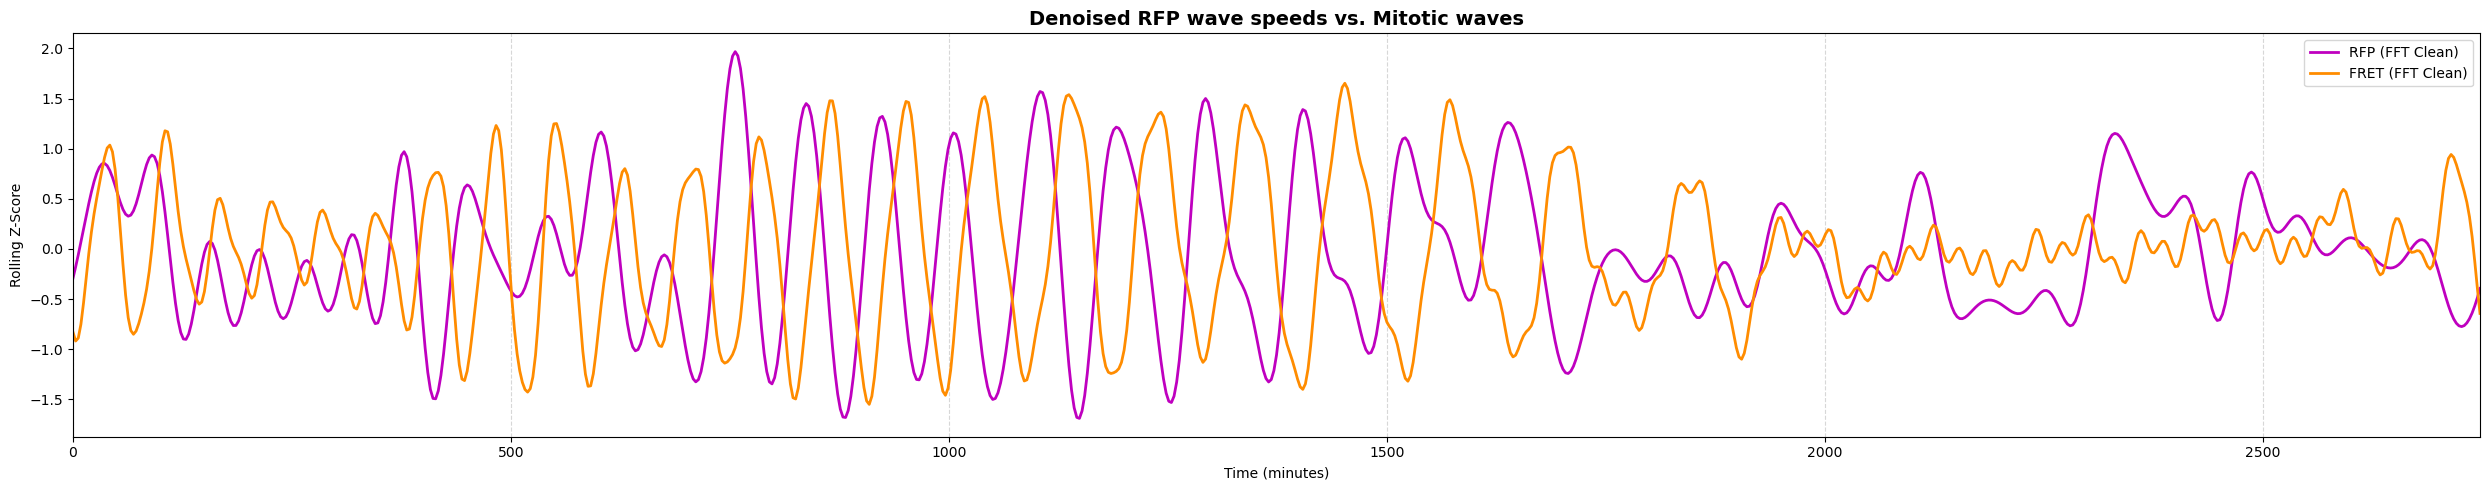

In [11]:
#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech, clean_ActivityMech, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito, clean_ActivityMito, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Rolling Z-Score')
plt.xlim(TimeMech.min(), TimeMech.max())
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Another cool thing we can do is **identify the peaks** in both of these data sets. This can be useful for roughly caluclating the period length.  

In [12]:
#finding the local peaks 
max_indMECH = argrelextrema(clean_ActivityMech, np.greater)[0]
max_indMITO = argrelextrema(clean_ActivityMito, np.greater)[0]
Mechmaxpts = clean_ActivityMech[max_indMECH]
Mitomaxpts = clean_ActivityMito[max_indMITO]

We can print our the **mechanical peaks** and **mitotic peaks**. 

Double check though that the correspdining Value makes sense. If not then the recorded peak is probably not relavent or might be a slight peak, not a major one. 

In [ ]:
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech.iloc[max_indMECH], Mechmaxpts):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(TimeMito.iloc[max_indMITO], Mitomaxpts):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

You can then record these values and **plot them**. For example:

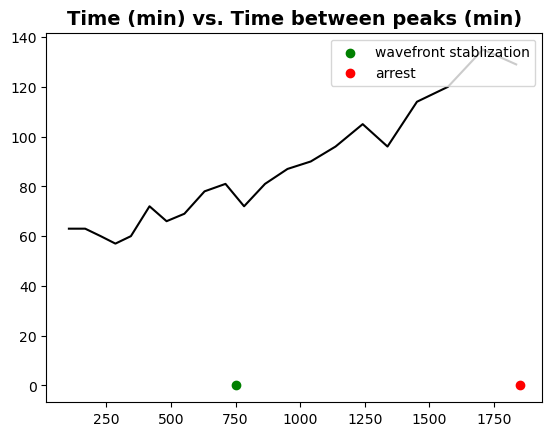

In [15]:
x9 = [105, 168, 228, 285, 345, 417, 483, 552, 630, 711, 783, 864, 951,1041, 1137, 1242, 1338, 1452, 1572, 1707, 1836]
y9 = [63, 63, 60, 57, 60, 72, 66, 69, 78, 81, 72, 81, 87, 90, 96, 105, 96, 114, 120, 135, 129]
plt.plot(x9,y9, color="black")
plt.scatter(750,0, color="green", label = "wavefront stablization")
plt.scatter(1850,0, color="red", label = "arrest")
plt.title('Time (min) vs. Time between peaks (min)', fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.show()

# End of Code!